Real-Time Credit Risk Simulation

Lightweight, real-time credit risk analysis pipeline that simulates event ingestion, processes streaming data in pandas, applies logistic regression for prediction, and generates actionable business recommendations.

Sets up the environment and imports `run_pipeline()`.

Checks if the output parquet file exists and deletes it to ensure a fresh pipeline run.

Prints a message to indicate whether the file was removed or not.


In [1]:
import sys
import pandas as pd
import threading
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

# -----------------------------
# Add project root to sys.path for module imports
# -----------------------------
root = "/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation"
sys.path.append(root)

# -----------------------------
# Import external python modules
# -----------------------------

from pathlib import Path
from src.pipeline import run_pipeline
from src.viz.plots import Plots
from src.preprocessing import data_transformations

# -----------------------------
# Display full dataframes
# -----------------------------

pd.set_option('display.max_rows', None) # reset_option to compact dataframe view
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

# -----------------------------
# Define path to processed parquet file
# -----------------------------
file_path = Path(
    '/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/processed/processed_df.parquet'
)

# -----------------------------
# Delete existing parquet file for a fresh execution
# -----------------------------
if file_path.exists():
    file_path.unlink()
    print(f"Deleted existing file: {file_path}", flush=True)
else:
    print("No existing parquet file found. Continuing...", flush=True)

Deleted existing file: /Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/processed/processed_df.parquet


Runs `run_pipeline()` in a separate thread so the notebook can monitor progress in real time.

Continuously reads the output parquet file and prints changes to the DataFrame whenever new events are added.

In [2]:
# -----------------------------
# Initialize variables
# -----------------------------
previous_shape = (0, 0)
current_df = pd.DataFrame(columns=[])

# -----------------------------
# Start pipeline in a separate thread
# -----------------------------
pipeline_thread = threading.Thread(target=run_pipeline, daemon=True)
pipeline_thread.start()
print("Monitoring parquet file for updates...\n")

# -----------------------------
# Real-time monitoring loop
# -----------------------------
while pipeline_thread.is_alive():
    if file_path.exists():
        try:
            df = pd.read_parquet(file_path, engine='fastparquet')
            if not df.empty and df.shape != previous_shape:
                previous_shape = df.shape
        except Exception:
            pass
    time.sleep(0.05)

# -----------------------------
# Wait for pipeline thread to finish
# -----------------------------
pipeline_thread.join()

# -----------------------------
# Initialize final DataFrame as df
# -----------------------------
if file_path.exists():
    sns.set_theme()
    df = pd.read_parquet(file_path, engine='fastparquet')
    print(f"Initial DataFrame shape: {df.shape}\n")
else:
    print("Pipeline finished but file was not found.")

Monitoring parquet file for updates...

Event producing has initiated.
Event consuming has initiated.

Processing is complete.

Initial DataFrame shape: (45063, 8)



EDA, visualizations, and transformations are applied to each variable in the dataset as needed.

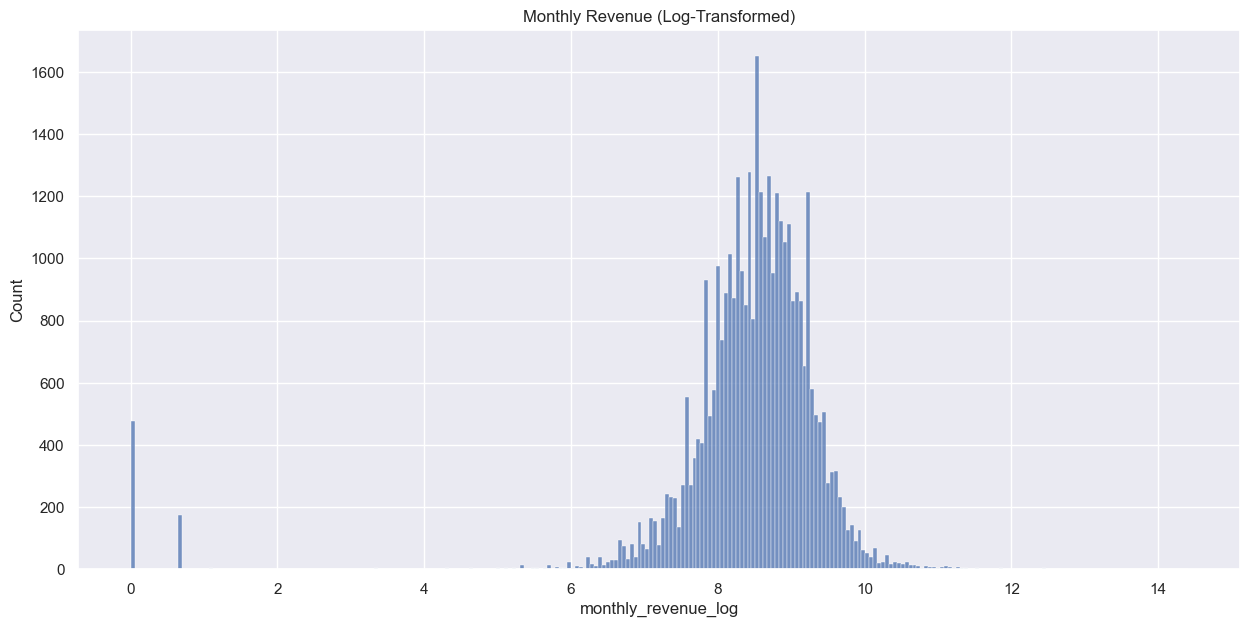

In [35]:
"""MONTHLY REVENUE"""

# Create the bins
monthly_revenue_raw = df[['monthly_revenue']].copy()

# Create revenue bins and labels
revenue_bins = [0, 5000, 10000, 15000, 20000, 25000, 50000, 100000, 999999999]
revenue_labels = ['0-5k', '5k-10k', '10k-15k', '15k-20k', '20k-25k', '25k-50k', '50k-100k', '100k+']

# Cut each row into its corresponding bin
monthly_revenue_raw['revenue_bin'] = pd.cut(monthly_revenue_raw['monthly_revenue'], 
                                            bins=revenue_bins, 
                                            labels=revenue_labels, 
                                            include_lowest=True)

# Add empty value category
monthly_revenue_raw['revenue_bin'] = (monthly_revenue_raw['revenue_bin'].cat.add_categories('NaN').fillna('NaN'))

# Display dataframe
monthly_revenue_raw.head()

"""Histogram Plot"""
x_var = 'revenue_bin'
plt.figure(figsize=(15,7))
# plt.title("Monthly Revenue (Binned)")
# sns.histplot(data=monthly_revenue_raw, x=x_var, log=True)

"""Log Transform Distribution"""
df['monthly_revenue_log'] = np.log1p(df['monthly_revenue'])
plt.title("Monthly Revenue (Log-Transformed)")
sns.histplot(df['monthly_revenue_log'])

# Add revenue bin column to the original dataframe
df['revenue_bin'] = monthly_revenue_raw['revenue_bin']


Final DataFrame shape: (45063, 8)

NULL monthly_revenue: 8643


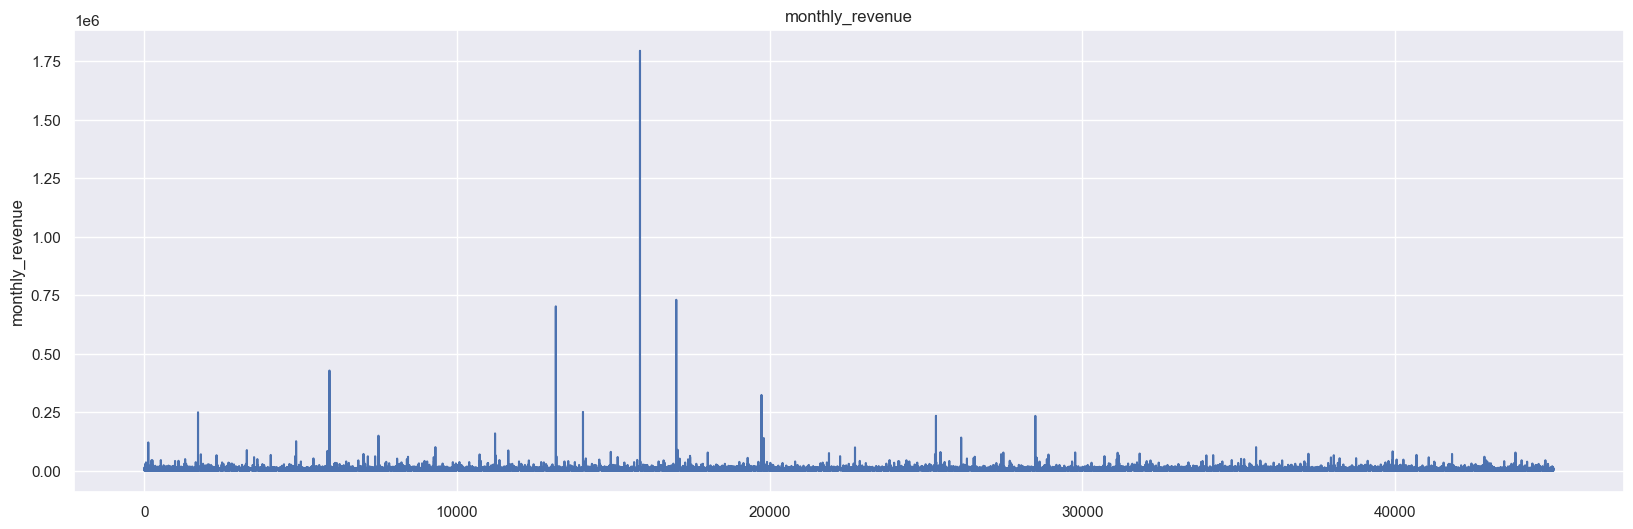

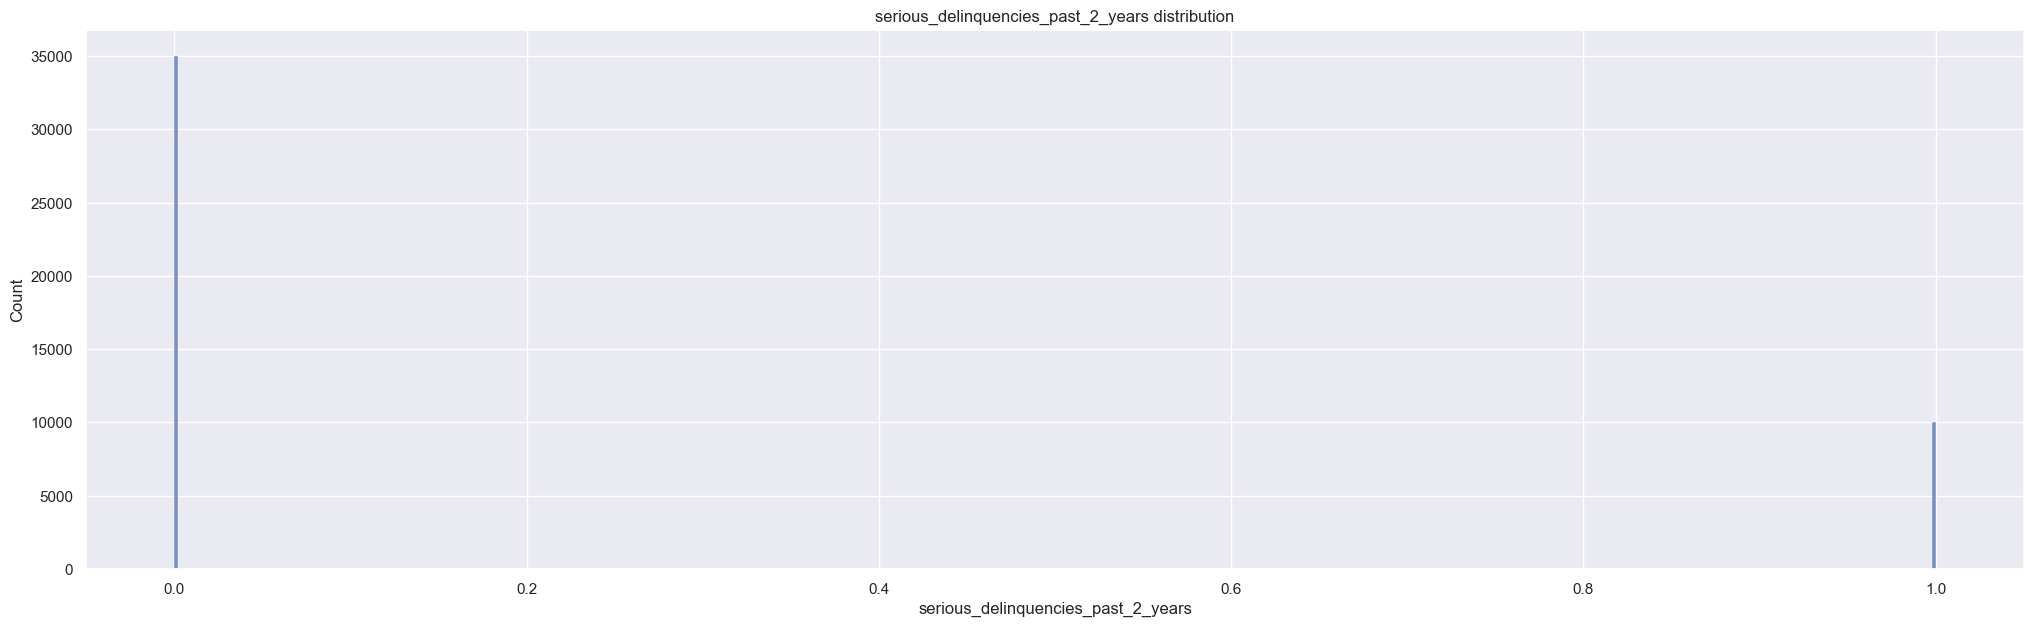

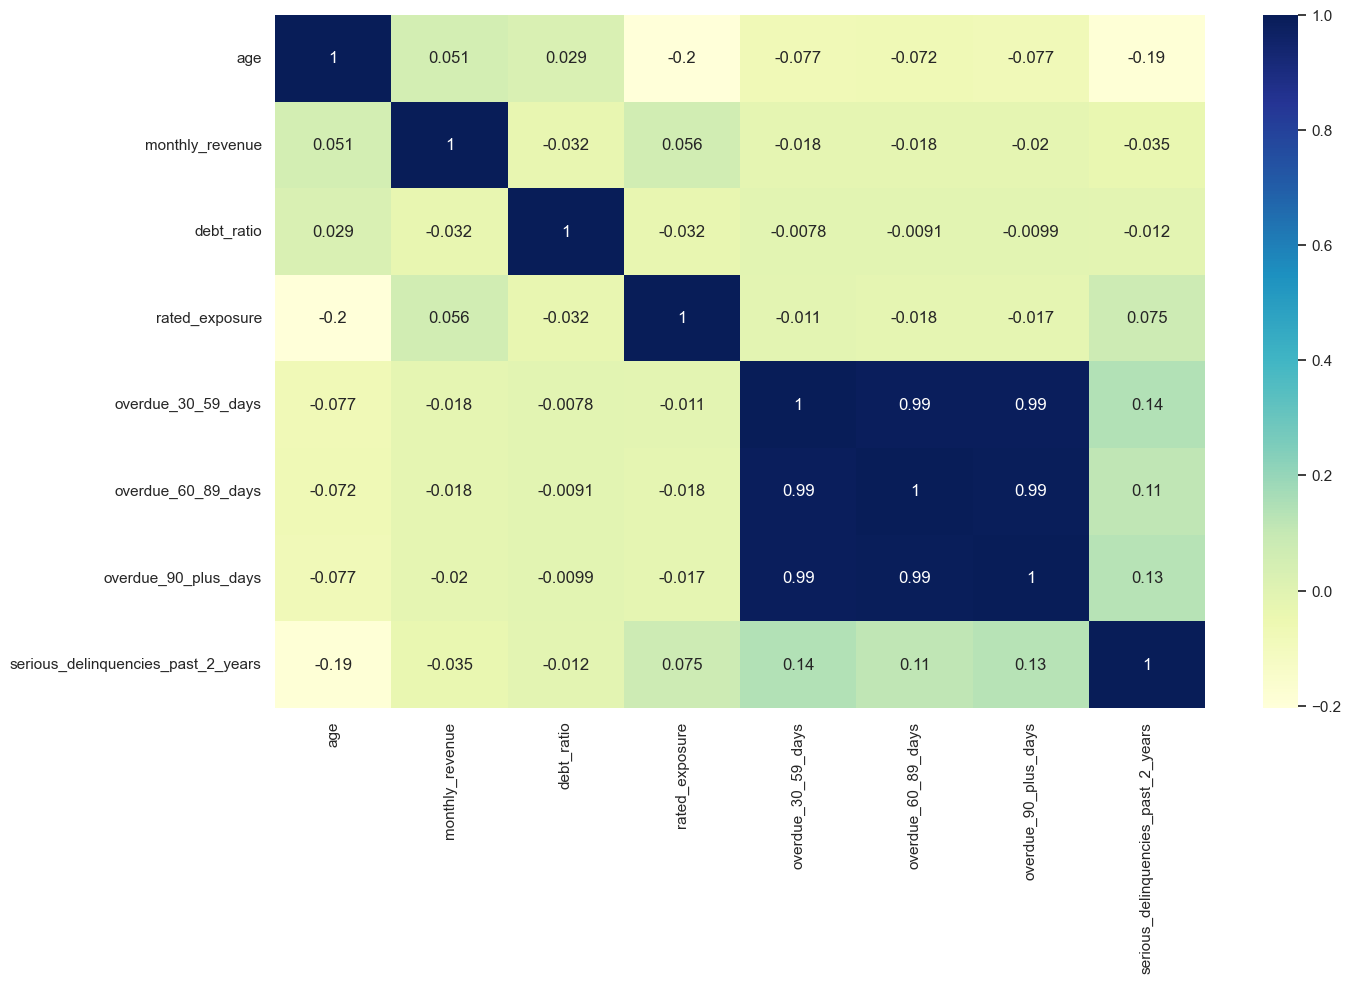

In [4]:
"""Seaborn and Line Plots"""
# plt.figure(figsize=(16,6))
# sns.lineplot(data=df['monthly_revenue']) # original

"""Removing Outliers"""
# df = df[(df['monthly_revenue'] < 100000)] # removes rows with a monthly_revenue above $100,000
# df = df[(df['overdue_90_plus_days'] < 12)] # removes rows with a overdue_90_plus_days above 12
# df = df[(df['overdue_60_89_days'] < 9)] # removes rows with a overdue_60_89_days above 9
# df = df[(df['overdue_30_59_days'] < 14)] # removes rows with a overdue_30_59_days above 14
# df = df[(df['debt_ratio'] < 200000)] # removes rows with a debt_ratio above 200,000
# df = df[(df['rated_exposure'] < 7)] # removes rows with a rated_exposure above 7

print(f"Final DataFrame shape: {df.shape}\n")

current_var = 'monthly_revenue'

"""Count of Null Values"""
is_null_series = df[current_var].isnull()
null_count = is_null_series.sum()
print(f"NULL {current_var}: {null_count}")

"""Line Plots"""
plt.figure(figsize=(20,6))
plt.title(current_var)
sns.lineplot(data=df[current_var])

"""Bar Plots"""
# x_var = 'rated_exposure'
# y_var = 'age'
# plt.figure(figsize=(25,7))
# plt.title(f'{x_var} vs. {y_var}')
# sns.barplot(x=df[x_var], y=df[y_var])

"""Scatter Plots"""
# x_var = 'rated_exposure'
# y_var = 'age'
# plt.figure(figsize=(25,7))
# plt.title(f'{x_var} vs. {y_var}')
# sns.scatterplot(x=df[x_var], y=df[y_var])

"""Histogram Plots"""
x_var = 'serious_delinquencies_past_2_years'
plt.figure(figsize=(25,7))
plt.title(f'{x_var} distribution')
sns.histplot(data=df, x=x_var)

"""Pie Graphs (Custom)"""
# plt.figure(figsize=(25,9))
# Plots.plot_age_ranges(df, 'age', title='% of Age Ranges')

"""Correlation Matrix"""
correlation_matrix = df.corr()
plt.figure(figsize=(15,9))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu')
plt.show()

The describe() function was also added to provide quick descriptive statistics of the final dataframe.

In [5]:
df.describe()

,age,monthly_revenue,debt_ratio,rated_exposure,overdue_30_59_days,overdue_60_89_days,overdue_90_plus_days,serious_delinquencies_past_2_years
count,45063.000000,36420.000000,45063.000000,43946.000000,45063.000000,45063.000000,45063.000000,45063.000000
mean,51.210949,6452.263399,352.062688,0.789628,0.750993,0.505870,0.570712,0.222489
std,14.651533,12638.167723,2467.556358,1.130813,6.184521,6.153609,6.173106,0.415922
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,3286.000000,0.176373,0.000000,0.000000,0.000000,0.000000,0.000000
50%,51.000000,5166.000000,0.373949,0.000000,0.000000,0.000000,0.000000,0.000000
75%,62.000000,8000.000000,0.857027,1.000000,0.000000,0.000000,0.000000,0.000000
max,107.000000,1794060.000000,326442.000000,10.000000,98.000000,98.000000,98.000000,1.000000


The following code contains data transformations applied to the final dataframe to prepare it for analysis and visualization.

In [6]:
# Enforce monotonic severity for delinquencies
df = data_transformations.backfill_overdues(df, col_1='overdue_30_59_days', col_2='overdue_60_89_days', col_3='overdue_90_plus_days')